In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "3"

In [3]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from tqdm import tqdm, trange

from datasets import load_dataset
import pandas as pd
import functools
import sys
from pathlib import Path
from typing import Callable

# import circuitsvis as cv
import einops
import numpy as np
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import eindex
# from IPython.display import display
from jaxtyping import Float, Int
from torch import Tensor
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset, Dataset, DatasetDict
from transformers import AutoTokenizer
import os
import json
import matplotlib.pyplot as plt
import math
import seaborn as sns

/home/kokil/shaz/interp-toxicity/interp-toxicity2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
print("Available CUDA devices:", torch.cuda.device_count())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

Available CUDA devices: 1
Device 0: NVIDIA H100 80GB HBM3


In [5]:
tokenizer  = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    output_attentions=True      # optional
).to(device)
model.eval()
model.load_state_dict(torch.load('toxigen/model_epoch_2_acc_0.8490.pt', map_location=device))

2025-06-12 10:10:19.068355: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-12 10:10:19.081735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749723019.098458 1807617 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749723019.103372 1807617 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749723019.116443 1807617 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

<All keys matched successfully>

## Patching

In [6]:
import math
import torch
import torch.nn as nn
from contextlib import contextmanager
from tqdm import trange

from transformers import BertModel, BertForSequenceClassification


# ----------------------------------------------------------------------------------------------------------------------
# 1) Helpers: Build a patched forward() that accepts *args, **kwargs
# ----------------------------------------------------------------------------------------------------------------------

def _make_patched_forward(self, head_to_zero: int):
    """
    Returns a function that can be bound to `BertSelfAttention.forward`
    in order to zero out `head_to_zero` right after the Softmax.
    """

    num_heads = self.num_attention_heads
    head_dim   = self.attention_head_size
    all_head_size = self.all_head_size

    def patched_forward(self, *args, **kwargs):
        """
        A drop-in replacement for BertSelfAttention.forward that zeroes one head.
        We expect this to be bound on `self = layer.attention.self`.
        """

        # --------------------------------------------------------------------------------
        # Step 1: Extract the actual arguments from *args and **kwargs
        # --------------------------------------------------------------------------------
        # In HuggingFace v4, the signature is roughly:
        #    def forward(
        #         self,
        #         hidden_states,
        #         attention_mask=None,
        #         head_mask=None,
        #         encoder_hidden_states=None,
        #         encoder_attention_mask=None,
        #         past_key_value=None,
        #         output_attentions=False,
        #         output_hidden_states=False,
        #         return_dict=True,
        #    ):
        #
        # We only care about hidden_states, attention_mask, head_mask, output_attentions for our patch.
        # Everything else we will ignore or pass through as-is when returning.

        # hidden_states is always the first positional argument:
        hidden_states = args[0]

        # The other parameters might come positionally or as keywords. We'll check both.
        attention_mask      = kwargs.get("attention_mask", None)
        head_mask           = kwargs.get("head_mask", None)
        output_attentions   = kwargs.get("output_attentions", False)

        # (We do NOT need encoder_hidden_states, etc., because BERT's BertSelfAttention
        #  does not use them in its own mask + softmax + matmul code path. Those are for cross-attention.)
        #
        # If you have a model where cross-attention is used inside the same class,
        # you would need to pull out encoder_hidden_states/encoder_attention_mask, etc.
        # But for plain BERT, we can ignore them.

        # --------------------------------------------------------------------------------
        # Step 2: Copy HuggingFace's logic up to (and after) softmax
        # --------------------------------------------------------------------------------
        mixed_query_layer = self.query(hidden_states)
        mixed_key_layer   = self.key(hidden_states)
        mixed_value_layer = self.value(hidden_states)
        # At this point: mixed_value_layer has shape (batch_size, seq_len, all_head_size).

        # A helper to reshape (batch, seq_len, all_head_size) → (batch, heads, seq_len, head_dim)
        def transpose_for_scores(x):
            new_shape = x.size()[:-1] + (num_heads, head_dim)
            x = x.view(*new_shape)
            return x.permute(0, 2, 1, 3)  # (batch, heads, seq_len, head_dim)

        query_layer = transpose_for_scores(mixed_query_layer)  # (B, H, S, head_dim)
        key_layer   = transpose_for_scores(mixed_key_layer)    # (B, H, S, head_dim)
        value_layer = transpose_for_scores(mixed_value_layer)  # (B, H, S, head_dim)

        # 1) Compute raw attention scores
        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))  # (B, H, S, S)
        attention_scores = attention_scores / math.sqrt(head_dim)

        # 2) If there is an attention_mask, add it
        if attention_mask is not None:
            attention_scores = attention_scores + attention_mask

        # 3) Softmax → attention_probs, then dropout
        attention_probs = torch.nn.functional.softmax(attention_scores, dim=-1)
        attention_probs = torch.nn.functional.dropout(
            attention_probs,
            p=self.dropout.p if hasattr(self, "dropout") else 0.1,
            training=self.training
        )

        # --------------------------------------------------------------------------------
        # Step 3: Zero out exactly head_to_zero in attention_probs
        # --------------------------------------------------------------------------------
        # We clone first to avoid in-place side-effects in subsequent layers
        attention_probs = attention_probs.clone()
        attention_probs[:, head_to_zero, :, :] = 0.0

        # --------------------------------------------------------------------------------
        # Step 4: Apply head_mask if provided (same as HF code)
        # --------------------------------------------------------------------------------
        if head_mask is not None:
            attention_probs = attention_probs * head_mask

        # --------------------------------------------------------------------------------
        # Step 5: Compute context = attention_probs @ value_layer
        #          (B, H, S, S)    @ (B, H, S, head_dim) → (B, H, S, head_dim)
        # --------------------------------------------------------------------------------
        context_layer = torch.matmul(attention_probs, value_layer)

        # --------------------------------------------------------------------------------
        # Step 6: Permute / reshape back to (batch, seq_len, all_head_size)
        # --------------------------------------------------------------------------------
        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()  # (B, S, H, head_dim)
        new_context_shape = context_layer.size()[:-2] + (all_head_size,)
        context_layer = context_layer.view(*new_context_shape)  # (B, S, hidden_size)

        # --------------------------------------------------------------------------------
        # Step 7: Build the return object exactly as BertSelfAttention does
        # --------------------------------------------------------------------------------
        outputs = (context_layer, attention_probs) if output_attentions else (context_layer,)
        
        # Finally return `outputs`. We do NOT return anything else (the calling code expects exactly
        # what HF returns: a tuple whose first element is context_layer, and second is attention_probs
        # if output_attentions=True).
        return outputs

    return patched_forward


@contextmanager
def zero_head(model: nn.Module, layer_idx: int, head_idx: int):
    """
    Temporarily patch layer `layer_idx`'s self-attention so that head `head_idx` is zeroed out
    right after the softmax. When we exit the context, we restore the original forward().

    Usage:
        with zero_head(model, layer_idx=0, head_idx=4):
            # Now layer0.head4 is disabled
            out = model(input_ids, attention_mask, labels=labels)
        # After the with-block, head 4 is restored.
    """
    # 1) Grab the BertSelfAttention submodule from the desired encoder layer
    layer_self_attn = model.bert.encoder.layer[layer_idx].attention.self

    # 2) Keep a reference to its original forward
    orig_forward = layer_self_attn.forward

    # 3) Create & bind our patched forward
    patched = _make_patched_forward(layer_self_attn, head_idx)
    layer_self_attn.forward = patched.__get__(layer_self_attn, type(layer_self_attn))

    try:
        yield
    finally:
        # 4) Restore the original forward method
        layer_self_attn.forward = orig_forward


# ----------------------------------------------------------------------------------------------------------------------
# 2) Main function: Compute Δ-loss for each (layer, head)
# ----------------------------------------------------------------------------------------------------------------------

def get_ablation_scores(
    classifier: nn.Module,
    input_ids:     torch.Tensor,
    attention_mask: torch.Tensor,
    labels:        torch.Tensor,
    criterion:     nn.Module,
):
    """
    For every (layer, head), temporarily zero out that head and compute:
        Δ-loss = Loss_with_head_zeroed − Loss_baseline.

    Returns:
      - scores:     torch.Tensor of shape (n_layers, n_heads) containing Δ-loss for each head
      - base_preds: torch.LongTensor of shape (batch_size,) with baseline predictions (no ablation)
      - predictions: dict mapping (layer, head) → torch.LongTensor of shape (batch_size,)
                     containing predictions when that head is zeroed.
    """

    n_layers = classifier.config.num_hidden_layers
    n_heads  = classifier.config.num_attention_heads
    device   = input_ids.device

    # 1) Compute the baseline (no head zeroed) loss & predictions
    classifier.eval()
    with torch.no_grad():
        # We call .forward(...) exactly as usual.
        base_out    = classifier(input_ids=input_ids,
                                 attention_mask=attention_mask,
                                 labels=labels,
                                 output_attentions=False)
        base_loss   = base_out.loss
        base_logits = base_out.logits
        base_preds  = torch.argmax(base_logits, dim=-1)

    # 2) Prepare containers
    scores      = torch.zeros(n_layers, n_heads, device=device)
    predictions = {}

    # 3) Loop over each layer & head
    for L in trange(n_layers, desc="Layers"):
        for H in range(n_heads):
            # Temporarily zero out head H in layer L
            with zero_head(classifier, layer_idx=L, head_idx=H):
                classifier.eval()
                with torch.no_grad():
                    out = classifier(input_ids=input_ids,
                                     attention_mask=attention_mask,
                                     labels=labels,
                                     output_attentions=False)
                    ablated_loss   = out.loss
                    ablated_logits = out.logits
                    ablated_preds  = torch.argmax(ablated_logits, dim=-1)

            # Δ-loss = ablated_loss − base_loss
            scores[L, H] = (ablated_loss - base_loss).detach()
            predictions[(L, H)] = ablated_preds.cpu()

    return scores.cpu(), base_preds.cpu(), predictions

In [7]:
criterion = nn.CrossEntropyLoss()

In [76]:
data = []
with open('pgd_log_toxigen', 'r') as f:
    for line in f:
        if line.strip():  # Skip empty lines
            tmp = json.loads(line)
            data.append(tmp)

In [77]:
len(data)

36200

In [78]:
df = pd.DataFrame(data)

In [79]:
from sentence_transformers import SentenceTransformer

emb_model = SentenceTransformer("all-MiniLM-L6-v2")

In [80]:
df.success.value_counts()

success
True     35580
False      620
Name: count, dtype: int64

In [81]:
embeddings1 = emb_model.encode(df.orig_text)
embeddings2 = emb_model.encode(df.adv_text)

In [82]:
similarities = emb_model.similarity(embeddings1, embeddings2)

In [83]:
df['similarity'] = similarities.diag().numpy()

(array([9.0000e+00, 3.8000e+01, 8.6000e+01, 2.4800e+02, 5.6200e+02,
        1.2960e+03, 2.9620e+03, 6.1790e+03, 1.1461e+04, 1.3359e+04]),
 array([0.12050296, 0.20845273, 0.29640251, 0.3843523 , 0.47230208,
        0.56025183, 0.64820158, 0.7361514 , 0.82410115, 0.91205096,
        1.00000072]),
 <BarContainer object of 10 artists>)

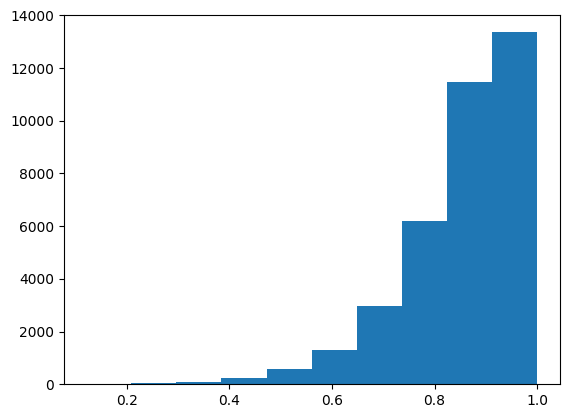

In [84]:
plt.hist(df.similarity)

In [85]:
df[df.similarity > 0.95]

,success,iters,id,orig_text,adv_text,orig_label,similarity
3,True,1,3,the only way to get a good job in the united s...,the common way to get a good job in the united...,1,0.968340
24,True,2,24,"if you have ever been to a mall, you will noti...","before you have ever been to a mall, you will ...",1,0.969461
39,True,3,39,"if you have ever been to the zoo, you have pro...","if you have ever been to the zoo, you have tra...",1,0.967405
42,True,1,42,the best way to insult someone is to tell them...,the common way to insult someone is to tell th...,1,0.969327
54,True,2,54,"there is no such thing as a ""_________ (fill i...","there is often this thing as a "" _ _ _ _ _ _ _...",1,0.962768
...,...,...,...,...,...,...,...
36170,True,10,36170,hard working,hard working,1,1.000000
36172,True,1,36172,i was on the T the other day. some guy though...,i was on the t the other day. some i thought i...,1,0.986616
36182,True,2,36182,didnt they just get here like 2-3 years ago?,didn - they just get here about 2 - 3 years ago?,1,0.956479
36190,True,1,36190,mexicans shouldnt be allowed to have dual cit...,mexicans shouldnt be presumed to have dual cit...,1,0.962601


In [86]:
df[df.similarity > 0.95].reset_index(drop=True).rename(columns={"orig_text": "original_text", "adv_text": "perturbed_text", "orig_label": "ground_truth_output"}).to_csv('pgd_log_toxigen_similar.csv', index=False)

In [87]:
df

,success,iters,id,orig_text,adv_text,orig_label,similarity
0,True,4,0,"no matter how much money or power you have, if...",no matter how much knowledge or power you have...,1,0.623704
1,True,2,1,the only thing that can be done to improve the...,the only thing that can be done to improve the...,1,0.475345
2,True,2,2,the only way to get ahead in america is to be ...,the dominant way to get ahead in america is to...,1,0.911004
3,True,1,3,the only way to get a good job in the united s...,the common way to get a good job in the united...,1,0.968340
4,True,4,4,blacks have been genetically bred to be the pe...,jews have been genetically bred to be the perf...,1,0.549030
...,...,...,...,...,...,...,...
36195,True,7,36195,blacks are too unorganized to have a real rev...,blacks are too diverse. ized to have a real re...,1,0.831898
36196,True,2,36196,we shouldnt need papers to live. america is a...,we often need papers to live. america is a fre...,1,0.978400
36197,True,4,36197,"i have nothing against gay people, i just thi...","i have nothing that gay anyone, i just think t...",1,0.895927
36198,True,3,36198,white men really shouldn't hate on white wome...,white men really shouldn ' t hate on white wom...,1,0.896127


In [88]:
df.rename(columns={"orig_text": "original_text", "adv_text": "perturbed_text", "orig_label": "ground_truth_output"}).to_csv('pgd_log_toxigen.csv', index=False)

In [19]:
df = pd.read_csv('pgd_log2.csv')

In [20]:
df[df.success].reset_index(drop=True).to_csv('pgd_log2_successful.csv', index=False)

In [21]:
df[df.success]

,success,iters,id,original_text,perturbed_text,ground_truth_output,error
1,True,1.0,1,Dear god this site is horrible,dear god this bitch is horrible,0,NaN
2,True,1.0,2,Somebody will invariably try to add Religion ...,somebody will fucking try to add religion real...,0,NaN
8,True,1.0,8,Arabs are committing genocide in Iraq but no p...,arabs are committing genocide in iraq but no p...,1,NaN
19,True,1.0,20,Id never think Id need to say it but Wikipedia...,id never think id need to say it but wikipedia...,0,NaN
21,True,2.0,22,DJ Robinson is gay as hell he sucks his dick s...,dj robinson is gay as hell he tells his friend...,1,NaN
...,...,...,...,...,...,...,...
59062,True,1.0,59932,added at by \n\n Somebody using the same IP a...,added at by somebody using the same ip as you ...,0,NaN
59071,True,1.0,59942,Lucky bastard \n httpwikimediafoundationorgwik...,* bastard httpwikimediafoundationorgwikipressr...,0,NaN
59072,True,1.0,59943,shame on you all \n\n You want to speak about ...,shame on you all you want to speak about *s an...,0,NaN
59073,True,1.0,59944,MEL GIBSON IS A NAZI BITCH WHO MAKES SHITTY MO...,"mel gibson is a nazi, who makes shitty movies ...",1,NaN


In [8]:
df[df.result_type == "Successful"].reset_index(drop=True).to_csv('textfooler_log_successful.csv')

In [24]:
dataset = load_dataset("csv", data_files={"pgd_log_toxigen_similar.csv"})
# dataset = Dataset.from_pandas(df.groupby('toxic').sample(n=1000).reset_index(drop=True))
# dataset = load_dataset('csv', data_files={'test': 'toxigen_alice.csv'})
# Tokenization function
def tokenize_data(example):
    return tokenizer(example["perturbed_text"], padding="max_length", truncation=True, max_length=128, return_tensors="pt")

# Apply tokenization
dataset = dataset.map(tokenize_data, batched=True)
dataset = dataset.rename_column("ground_truth_output", "labels")  # Rename for consistency
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Generating train split: 6045 examples [00:00, 215493.78 examples/s]
Map: 100%|██████████| 6045/6045 [00:00<00:00, 11954.90 examples/s]


In [25]:
class JigsawDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return {key: self.dataset[idx][key] for key in ["input_ids", "labels", "attention_mask"]}

# Create PyTorch DataLoaders
batch_size = 256
val_dataloader = DataLoader(JigsawDataset(dataset['train']), batch_size=batch_size, shuffle=False)

In [26]:
print('patching')
ablation_scores = torch.zeros(12,12, device=device)
base_preds = []
ablated_preds = {layer: {head : [] for head in range(model.config.num_attention_heads)} for layer in range(model.config.num_hidden_layers)}
for i, batch in tqdm(enumerate(val_dataloader), total=len(val_dataloader)):
    input_ids, labels, attention_mask = batch["input_ids"].to(device), batch["labels"].to(device), batch["attention_mask"].to(device)
    tmp_ablation_scores, base_pred, ablated_pred_list = get_ablation_scores(model, input_ids, attention_mask, labels, criterion)
    ablation_scores += tmp_ablation_scores.to(device)
    base_preds += base_pred.tolist()
    for layer in range(model.config.num_hidden_layers):
        for head in range(model.config.num_attention_heads):
            ablated_preds[layer][head] += ablated_pred_list[(layer, head)].tolist()
    # if i == 16:
    #     break

# ablation_scores /= len(val_dataloader)
# torch.save(ablation_scores, "bert_ablation_scores_jigsaw_perturbed.pth")

patching


100%|██████████| 24/24 [07:32<00:00, 18.86s/it]


## Testing

In [6]:
dataset = load_dataset("csv", data_files={"input_reduction_log.csv"})
# dataset = Dataset.from_pandas(df.groupby('toxic').sample(n=1000).reset_index(drop=True))
# dataset = load_dataset('csv', data_files={'test': 'toxigen_alice.csv'})
# Tokenization function
def tokenize_data(example):
    return tokenizer(example["perturbed_text"], padding="max_length", truncation=True, max_length=128, return_tensors="pt")

# Apply tokenization
dataset = dataset.map(tokenize_data, batched=True)
dataset = dataset.rename_column("ground_truth_output", "labels")  # Rename for consistency
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Generating train split: 2500 examples [00:00, 46016.61 examples/s]
Map: 100%|██████████| 2500/2500 [00:00<00:00, 9569.89 examples/s] 


In [7]:
class JigsawDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return {key: self.dataset[idx][key] for key in ["input_ids", "labels", "attention_mask"]}

# Create PyTorch DataLoaders
batch_size = 64
val_dataloader = DataLoader(JigsawDataset(dataset['train']), batch_size=batch_size, shuffle=False)

In [11]:
print('patching')
ablation_scores = torch.zeros(12,12, device=device)
base_preds = []
ablated_preds = {layer: {head : [] for head in range(model.config.num_attention_heads)} for layer in range(model.config.num_hidden_layers)}
for i, batch in tqdm(enumerate(val_dataloader), total=len(val_dataloader)):
    input_ids, labels, attention_mask = batch["input_ids"].to(device), batch["labels"].to(device), batch["attention_mask"].to(device)
    tmp_ablation_scores, base_pred, ablated_pred_list = get_ablation_scores(model, input_ids, attention_mask, labels, criterion)
    ablation_scores += tmp_ablation_scores.to(device)
    base_preds += base_pred.tolist()
    for layer in range(model.config.num_hidden_layers):
        for head in range(model.config.num_attention_heads):
            ablated_preds[layer][head] += ablated_pred_list[(layer, head)].tolist()
    if i == 16:
        break

# ablation_scores /= len(val_dataloader)
# torch.save(ablation_scores, "bert_ablation_scores_jigsaw_perturbed.pth")

patching


 15%|█▌        | 6/40 [14:09<1:20:11, 141.52s/it]


KeyboardInterrupt: 

## Analysis

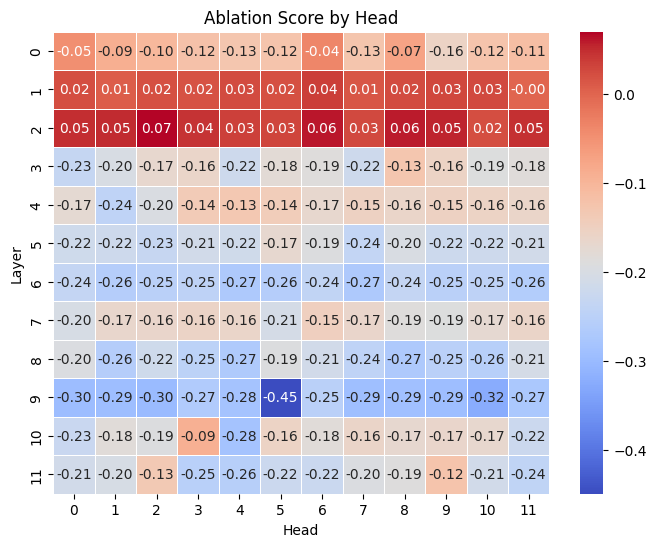

In [27]:
tensor_np = ablation_scores.cpu().detach().numpy() / 10
# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap(tensor_np, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Ablation Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

# plt.savefig(f'textfooler/bert_jigsaw_perturbed_ablation_scores_by_head.png')


# Show the plot
plt.show()

In [28]:
df = pd.read_csv('pgd_log_toxigen_similar.csv')

In [29]:
acc_scores = np.zeros((12,12))
for i in range(12):
    for j in range(12):
        acc_scores[i][j] = np.mean(df.ground_truth_output == np.array(ablated_preds[i][j]))

In [30]:
base_acc = np.mean(df.ground_truth_output == np.array(base_preds))
base_acc

0.02795698924731183

In [44]:
len(base_preds)

6045

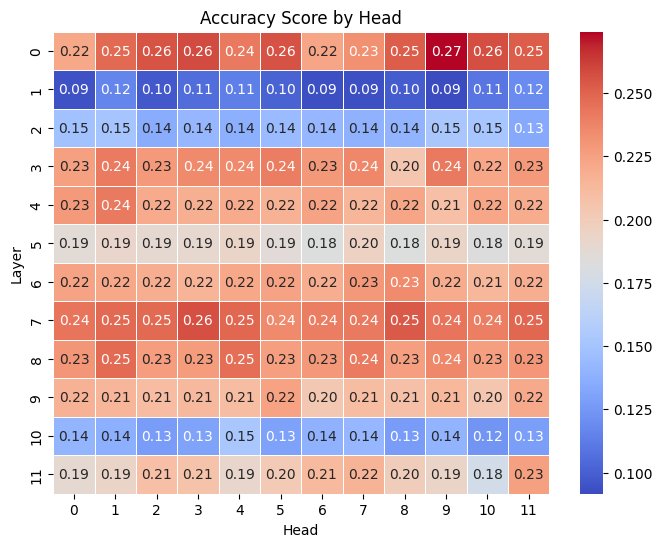

In [32]:
# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap((acc_scores - base_acc), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Accuracy Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

# plt.savefig(f'textfooler/bert_jigsaw_perturbed_accuracy_scores_by_head.png')
# Show the plot
plt.show()

In [61]:
len(ablated_preds[0][0])

6045

In [72]:
similar_df = pd.read_csv('pgd_log_toxigen_similar.csv').rename(columns={"original_text": "generation"})

In [73]:
similar_df['best_preds'] = ablated_preds[0][9] == similar_df.ground_truth_output

In [74]:
similar_df_full = pd.merge(similar_df, df, on='generation', how='left')

In [75]:
similar_df_full.groupby('group').agg({'best_preds': 'mean'}).sort_values('best_preds', ascending=False)

,best_preds
group,
jewish,0.377682
physical_dis,0.364706
asian,0.354144
lgbtq,0.351351
mexican,0.333333
women,0.327273
chinese,0.322344
native_american,0.278492
latino,0.267811


In [33]:
max_value = np.max(acc_scores)
max_indices = np.unravel_index(np.argmax(acc_scores), acc_scores.shape)
print("Maximum value:", max_value)
print("Indices of maximum value (layer, head):", max_indices)

Maximum value: 0.3022332506203474
Indices of maximum value (layer, head): (0, 9)


In [49]:
sim_df = pd.read_csv('pgd_log_toxigen.csv').rename(columns={"original_text": "generation"})
df = pd.read_csv('toxigen/test_clean.csv')

In [51]:
new_df = pd.merge(sim_df, df, on='generation', how='left')

In [52]:
new_df.group.value_counts()

group
asian              5481
black              5121
muslim             5110
native_american    5079
latino             4693
chinese            2827
jewish             2653
lgbtq              1827
women               422
mexican             356
middle_east         311
mental_dis          302
physical_dis        299
Name: count, dtype: int64

In [56]:
new_df1 = new_df[new_df.prompt_label == 1]
new_df0 = new_df[new_df.prompt_label == 0]

In [57]:
new_df0.groupby('group').agg({'similarity': 'median'}).sort_values('similarity', ascending=False)

,similarity
group,
chinese,0.941137
jewish,0.941137
mental_dis,0.941137
physical_dis,0.941137
latino,0.916042
middle_east,0.909702
mexican,0.906484
muslim,0.906270
native_american,0.903804


In [58]:
new_df1.groupby('group').agg({'similarity': 'median'}).sort_values('similarity', ascending=False)

,similarity
group,
mental_dis,0.941137
physical_dis,0.925476
women,0.899052
lgbtq,0.890060
native_american,0.886930
muslim,0.886596
chinese,0.884449
latino,0.883359
mexican,0.882034
